<a href="https://colab.research.google.com/github/cedricguilmin/analytics_mining/blob/main/countries_ue_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
!pip install skimpy

In [56]:
import numpy as np
import pandas as pd
from skimpy import skim
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from matplotlib import pyplot as plt
from sklearn import metrics

In [57]:
# Before executing that cell, you have to make sure you have mount your drive
# to be accessible from Colab runtime
countries_ue = pd.read_csv('/content/drive/MyDrive/00_datamining/countries_ue.txt', sep = '\t')

In [58]:
countries_ue.shape

(27, 13)

In [59]:
countries_ue.head()

,Pays,PIB,Dep_pub,Rev_net,Esp_vie,Chomage,Education,Gini,Securite,Adhesion,OCDE,Localisation,Rating
0,BE,32700.0,17187.5,20.8,80.3,8.3,30.0,26.6,96.3,1957,OCDE,Ouest,2
1,BG,4800.0,1790.8,15.1,73.8,10.3,20.7,33.2,18.3,2007,Non-OCDE,Est,4
2,CZ,14300.0,6261.6,16.6,77.7,7.3,15.3,24.9,31.7,2004,Non-OCDE,Est,3
3,DK,42500.0,24562.8,26.7,79.3,7.5,29.5,26.9,88.9,1973,OCDE,Nord,1
4,DE,30500.0,14503.3,17.2,80.5,7.1,24.3,29.3,74.0,1957,OCDE,Ouest,1


In [60]:
countries_ue.describe()

,PIB,Dep_pub,Rev_net,Esp_vie,Chomage,Education,Gini,Securite,Adhesion,Rating
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,23607.407407,11858.466667,17.048148,78.907407,10.103704,23.844444,29.540741,49.685185,1987.148148,2.518519
std,15627.636416,7964.215088,4.857221,2.988944,4.463397,7.505912,3.913120,31.777371,19.520608,1.369176
min,4800.000000,1790.800000,6.900000,73.500000,4.400000,11.900000,23.800000,8.700000,1957.000000,1.000000
25%,11400.000000,4825.850000,13.750000,76.200000,7.300000,18.250000,26.000000,27.000000,1973.000000,1.000000
50%,20700.000000,10091.100000,16.600000,80.300000,8.400000,24.400000,29.300000,40.000000,1995.000000,3.000000
75%,33000.000000,17570.400000,19.100000,81.000000,12.300000,30.450000,33.100000,72.300000,2004.000000,3.000000
max,78600.000000,33738.500000,28.000000,82.300000,20.100000,34.100000,36.900000,150.500000,2007.000000,5.000000


In [61]:
skim(countries_ue)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 27     │ │ float64     │ 8     │                                                          │
│ │ Number of columns │ 13     │ │ string      │ 3     │                                                          │
│ └───────────────────┴────────┘ │ int64       │ 2     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column       ┃ NA   ┃ NA %   ┃ mean    ┃ sd      ┃ p0     ┃ p25     ┃ p50     ┃ p75     ┃ p100   ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩  │
│ │     PIB      │    0 │      0 │   23610 │   15630 │   4800 │   11400 │   20700 │   33000 │  78600 │ █▄▆▁ ▁  │  │
│ │   Dep_pub    │    0 │      0 │   11860 │    7964 │   1791 │    4826 │   10090 │   17570 │  33740 │ █▄▄▄▁▁  │  │
│ │   Rev_net    │    0 │      0 │   17.05 │   4.857 │    6.9 │   13.75 │    16.6 │    19.1 │     28 │ ▂▅██▁▃  │  │
│ │   Esp_vie    │    0 │      0 │   78.91 │   2.989 │   73.5 │    76.2 │    80.3 │      81 │   82.3 │ ▄▃▁▁█▇  │  │
│ │   Chomage    │    0 │      0 │    10.1 │   4.463 │    4.4 │     7.3 │     8.4 │    12.3 │   20.1 │ ▄█▃▂▁▂  │  │
│ │  Education   │    0 │      0 │   23.84 │   7.506 │   11.9 │   18.25 │    24.4 │   30.45 │   34.1 │ ▆▃▅▅▅█  │  │
│ │     Gini     │    0 │      0 │   29.54 │   3.913 │   23.8 │      26 │    29.3 │    33.1 │   36.9 │ █▅▅▃█▂  │  │
│ │   Securite   │    0 │      0 │   49.69 │   31.78 │    8.7 │      27 │      40 │    72.3 │  150.5 │ █▆▅▂ ▁  │  │
│ │   Adhesion   │    0 │      0 │    1987 │   19.52 │   1957 │    1973 │    1995 │    2004 │   2007 │ ▄▂▁▁▂█  │  │
│ │    Rating    │    0 │      0 │   2.519 │   1.369 │      1 │       1 │       3 │       3 │      5 │ █▄ ▇▃▃  │  │
│ └──────────────┴──────┴────────┴─────────┴─────────┴────────┴─────────┴─────────┴─────────┴────────┴─────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃             ┃    ┃      ┃          ┃          ┃          ┃      ┃ chars per    ┃ words per   ┃             ┃  │
│ ┃ column      ┃ NA ┃ NA % ┃ shortest ┃ longest  ┃ min      ┃ max  ┃ row          ┃ row         ┃ total words ┃  │
│ ┡━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │    Pays     │  0 │    0 │    BE    │    BE    │    AT    │  SK  │            2 │           1 │          27 │  │
│ │    OCDE     │  0 │    0 │   OCDE   │ Non-OCDE │ Non-OCDE │ OCDE │         5.04 │           1 │          27 │  │
│ │ Localisatio │  0 │    0 │   Est    │  Ouest   │   Est    │ Sud  │          3.7 │           1 │          27 │  │
│ │      n      │    │      │          │          │          │      │              │             │             │  │
│ └─────────────┴────┴──────┴──────────┴──────────┴──────────┴──────┴──────────────┴─────────────┴─────────────┘  │
╰────────────────────────────────────────────────────── 

In [63]:
features = ['PIB', 'Dep_pub', 'Rev_net', 'Esp_vie', 'Chomage', 'Education', 'Gini', 'Securite']
X = countries_ue[features].values
X_stand = StandardScaler().fit_transform(X)

In [64]:
type(X)

numpy.ndarray

In [65]:
X.shape

(27, 8)

In [66]:
X_stand[0]

array([ 0.59291118,  0.68186856,  0.78714194,  0.47478986, -0.41180814,
        0.83571651, -0.76582369,  1.49486236])

In [67]:
skim(pd.DataFrame(X_stand))

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 27     │ │ float64     │ 8     │                                                          │
│ │ Number of columns │ 8      │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column   ┃ NA  ┃ NA %  ┃ mean         ┃ sd     ┃ p0      ┃ p25      ┃ p50       ┃ p75     ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │        0 │   0 │     0 │   -9.252e-17 │  1.019 │  -1.226 │   -0.796 │   -0.1896 │  0.6125 │ 3.586 │ █▄▆▁ ▁ │  │
│ │        1 │   0 │     0 │    1.686e-16 │  1.019 │  -1.288 │  -0.8998 │   -0.2261 │  0.7309 │   2.8 │ █▄▄▄▁▁ │  │
│ │        2 │   0 │     0 │    2.303e-16 │  1.019 │  -2.129 │   -0.692 │  -0.09402 │  0.4305 │ 2.298 │ ▂▅██▁▃ │  │
│ │        3 │   0 │     0 │    7.278e-16 │  1.019 │  -1.844 │  -0.9231 │    0.4748 │  0.7134 │ 1.157 │ ▄▃▁▁█▇ │  │
│ │        4 │   0 │     0 │   -2.138e-16 │  1.019 │  -1.302 │  -0.6401 │    -0.389 │  0.5014 │ 2.282 │ ▄█▃▂▁▂ │  │
│ │        5 │   0 │     0 │    3.865e-16 │  1.019 │  -1.622 │  -0.7595 │   0.07543 │  0.8968 │ 1.392 │ ▆▃▅▅▅█ │  │
│ │        6 │   0 │     0 │   -8.635e-17 │  1.019 │  -1.495 │  -0.9221 │  -0.06269 │  0.9269 │ 1.916 │ █▅▅▃█▂ │  │
│ │        7 │   0 │     0 │   -1.151e-16 │  1.019 │  -1.314 │  -0.7275 │   -0.3106 │  0.7252 │ 3.233 │ █▆▅▂ ▁ │  │
│ └──────────┴─────┴───────┴──────────────┴────────┴─────────┴──────────┴───────────┴─────────┴───────┴────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [68]:
# setting distance_threshold=0 ensures we compute the full tree.
# see: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, compute_distances=True, linkage = 'ward')
model_applied = model.fit(X_stand)

In [69]:
# https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

In [70]:
countries_ue['Pays'].values

<ArrowStringArray>
['BE', 'BG', 'CZ', 'DK', 'DE', 'EE', 'IE', 'GR', 'ES', 'FR', 'IT', 'CY', 'LV',
 'LT', 'LU', 'HU', 'MT', 'NL', 'AT', 'PL', 'PT', 'RO', 'SI', 'SK', 'FI', 'SE',
 'GB']
Length: 27, dtype: str

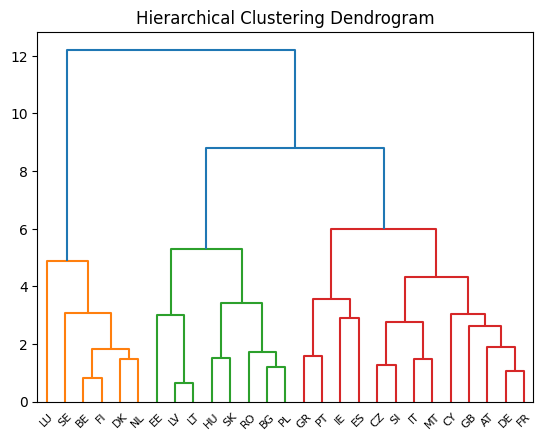

In [73]:
plt.title("Hierarchical Clustering Dendrogram")
# plot the whole tree
plot_dendrogram(model_applied, labels = countries_ue['Pays'].values, leaf_font_size = 8)
#plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

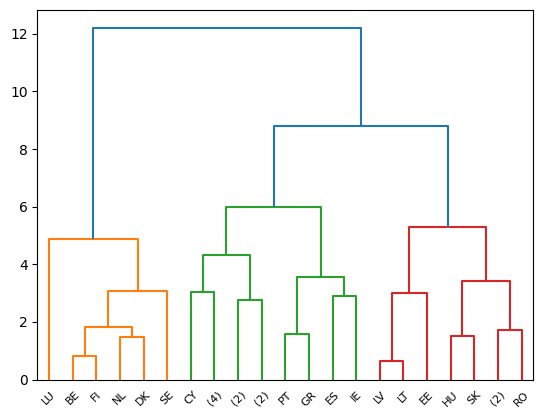

In [74]:
# You can also build an hierachical clustering with scipy
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html#scipy.cluster.hierarchy.linkage
model_applied_scipy = linkage(X_stand, method = 'ward', metric = 'euclidean', optimal_ordering=True)
dn = dendrogram(model_applied_scipy, labels = countries_ue['Pays'].values, leaf_font_size = 8, truncate_mode='level', p=4)  #
plt.show()

In [20]:
model_applied_scipy

array([[12.        , 13.        ,  0.63926235,  2.        ],
       [ 0.        , 24.        ,  0.82676628,  2.        ],
       [ 9.        ,  4.        ,  1.0654538 ,  2.        ],
       [19.        ,  1.        ,  1.20355424,  2.        ],
       [22.        ,  2.        ,  1.26013283,  2.        ],
       [16.        , 10.        ,  1.46000042,  2.        ],
       [17.        ,  3.        ,  1.47301548,  2.        ],
       [15.        , 23.        ,  1.5026869 ,  2.        ],
       [20.        ,  7.        ,  1.59046919,  2.        ],
       [30.        , 21.        ,  1.7325149 ,  3.        ],
       [28.        , 33.        ,  1.83713464,  4.        ],
       [29.        , 18.        ,  1.90017585,  3.        ],
       [26.        , 38.        ,  2.63517647,  4.        ],
       [31.        , 32.        ,  2.75033966,  4.        ],
       [ 8.        ,  6.        ,  2.88787896,  2.        ],
       [27.        ,  5.        ,  3.00510438,  3.        ],
       [11.        , 39.

In [21]:
countries_ue.iloc[[12,13]]

,Pays,PIB,Dep_pub,Rev_net,Esp_vie,Chomage,Education,Gini,Securite,Adhesion,OCDE,Localisation,Rating
12,LV,8100.0,3757.0,12.8,73.7,19.8,25.3,36.1,25.2,2004,Non-OCDE,Est,5
13,LT,8400.0,3428.8,12.8,73.5,17.8,28.1,36.9,22.9,2004,Non-OCDE,Est,4


In [26]:
X_stand[[12,13]]

array([[-1.01120942, -1.03661115, -0.89126536, -1.77541103,  2.21378587,
         0.19761528,  1.70815334, -0.78520062],
       [-0.99164697, -1.0786055 , -0.89126536, -1.84359894,  1.75716083,
         0.57776069,  1.91648824, -0.85895794]])

In [76]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.fcluster.html#scipy.cluster.hierarchy.fcluster
# fcluster = 'f' standing for flat clustering
countries_ue['cluster_5'] = fcluster(model_applied_scipy, t=5, criterion='maxclust')

In [77]:
countries_ue['cluster_5_scikit'] = AgglomerativeClustering(n_clusters=5, linkage = 'ward').fit_predict(X_stand)
countries_ue.groupby(['cluster_5', 'cluster_5_scikit']).size()

cluster_5  cluster_5_scikit
1          0                   6
2          2                   9
3          1                   4
4          4                   3
5          3                   5
dtype: int64

In [78]:
#countries_ue['PIB'] = countries_ue['PIB'].apply(lambda x: f"€{x:.2f}")
#concat
#var_2_export = ['Pays'] + features + ['cluster_5']
#print(var_2_export)
#countries_ue[var_2_export].to_csv('/content/drive/MyDrive/00_datamining/countries_ue_cluster.csv',
#                                 sep = ',', index = False, header = True)
#countries_pca = pd.concat([countries_ue, pd.DataFrame(X_new_space, columns=features_stand)], axis=1)

In [79]:
# there are some metrics of performance that can be applied in the
# context of clustering to compare
metrics.adjusted_rand_score(countries_ue['cluster_5'], countries_ue['cluster_5_scikit'])

1.0

In [80]:
# produce some satatistics by cluster to characterize/define your clusters
countries_ue.groupby('cluster_5').agg({'Pays': ['count', 'min', 'max'],
                                       'PIB' : ['mean'],
                                       'Dep_pub' : ['mean'],
                                       'Rev_net' : ['mean'],
                                       'Esp_vie' : ['mean'],
                                       'Chomage' : ['mean'],
                                       'Education' : ['mean'],
                                       'Gini' : ['mean'],
                                       'Securite' : ['mean']}).round(2)

Pays               PIB   Dep_pub Rev_net Esp_vie Chomage Education  \
          count min max      mean      mean    mean    mean    mean      mean   
cluster_5                                                                       
1             6  BE  SE  43300.00  21956.78   23.62   80.53    6.95     30.93   
2             9  AT  SI  23900.00  11891.43   17.43   80.68    7.26     21.33   
3             4  ES  PT  23400.00  12973.80   11.12   80.92   14.60     22.78   
4             3  EE  LV   9066.67   3844.80   15.50   74.40   18.17     29.17   
5             5  BG  SK   8340.00   3597.08   14.14   74.86   10.58     17.52   

            Gini Securite  
            mean     mean  
cluster_5                  
1          26.07    92.55  
2          28.40    48.16  
3          33.42    37.02  
4          34.77    28.07  
5          29.52    24.10

In [81]:
countries_ue.head()

,Pays,PIB,Dep_pub,Rev_net,Esp_vie,Chomage,Education,Gini,Securite,Adhesion,OCDE,Localisation,Rating,cluster_5,cluster_5_scikit
0,BE,32700.0,17187.5,20.8,80.3,8.3,30.0,26.6,96.3,1957,OCDE,Ouest,2,1,0
1,BG,4800.0,1790.8,15.1,73.8,10.3,20.7,33.2,18.3,2007,Non-OCDE,Est,4,5,3
2,CZ,14300.0,6261.6,16.6,77.7,7.3,15.3,24.9,31.7,2004,Non-OCDE,Est,3,2,2
3,DK,42500.0,24562.8,26.7,79.3,7.5,29.5,26.9,88.9,1973,OCDE,Nord,1,1,0
4,DE,30500.0,14503.3,17.2,80.5,7.1,24.3,29.3,74.0,1957,OCDE,Ouest,1,2,2


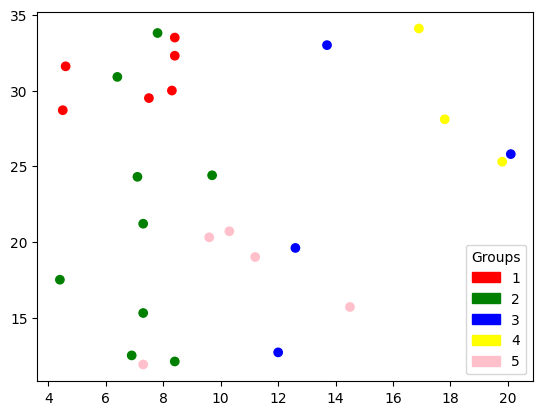

In [82]:
import matplotlib.patches as mpatches
color_map = {1: 'red', 2: 'green', 3: 'blue', 4 : 'yellow', 5 : 'pink' }
colors = [color_map[cat] for cat in countries_ue['cluster_5']]

# Plot
plt.scatter(countries_ue['Chomage'], countries_ue['Education'], c=colors)

# Create legend
patches = [mpatches.Patch(color=color, label=cat)
           for cat, color in color_map.items()]
plt.legend(handles=patches, title='Groups', loc = 'lower right')
plt.show()

In [83]:
# compute total within sum of squares for a specific level in cluster
twss = 0.0
cluster_labels = countries_ue['cluster_5']
clusters = np.unique(cluster_labels)
clusters

array([1, 2, 3, 4, 5], dtype=int32)

In [84]:
for cluster_id in clusters:
    # Extract points in the current cluster
    cluster_points = X_stand[cluster_labels == cluster_id]

    # Compute centroid (mean of points)
    centroid = np.mean(cluster_points, axis=0)

    # Sum squared distances from points to centroid
    squared_distances = np.sum((cluster_points - centroid) ** 2)
    twss += squared_distances

print(f"Total Within Sum of Squares: {twss}")

Total Within Sum of Squares: 70.70131063617464


In [35]:
cluster_points

array([[-1.22639633, -1.28819336, -0.40872326, -1.74131708,  0.0448169 ,
        -0.42690934,  0.9529393 , -1.00647256],
       [-0.90687637, -0.90278457, -0.19892235, -1.4344715 ,  0.25029817,
        -0.65771191, -1.41687027, -0.33303624],
       [-0.93295963, -0.97802124, -0.5555839 , -0.8548743 , -0.11500186,
        -0.48121583,  0.40606017, -0.64409968],
       [-1.16118817, -1.21945673, -0.82832509, -1.74131708, -0.64012067,
        -1.62165208,  0.97898116, -1.14436666],
       [-0.7503768 , -0.8969115 , -1.05910609, -1.12762593,  1.0037295 ,
        -1.10574044, -0.94811673, -0.97440416]])

In [36]:
centroid

array([-0.99555946, -1.05707348, -0.61013214, -1.37992118,  0.10874441,
       -0.85864592, -0.00540128, -0.82047586])

In [85]:
#prepare a dataframe that will hold TWSS
max_number_cluster = min(30, countries_ue.shape[0])
twssdf = pd.DataFrame({
    'nbr_cluster': range(2, 2 + max_number_cluster),
    'twss': [np.nan] * max_number_cluster
})
twssdf.head()

,nbr_cluster,twss
0,2,NaN
1,3,NaN
2,4,NaN
3,5,NaN
4,6,NaN


In [87]:
for nbr_cluster in twssdf.nbr_cluster:
  # compute total within sum of squares for a specific level in cluster
  twss = 0.0
  cluster_labels = fcluster(model_applied_scipy, t=nbr_cluster, criterion='maxclust')
  clusters = np.unique(cluster_labels)

  for cluster_id in clusters:
      # Extract points in the current cluster
      cluster_points = X_stand[cluster_labels == cluster_id]

      # Compute centroid (mean of points)
      centroid = np.mean(cluster_points, axis=0)

      # Sum squared distances from points to centroid
      squared_distances = np.sum((cluster_points - centroid) ** 2)
      twss += squared_distances

  twssdf.loc[twssdf.nbr_cluster == nbr_cluster, 'twss'] = twss

In [88]:
twssdf.head()

,nbr_cluster,twss
0,2,141.343543
1,3,102.664264
2,4,84.750393
3,5,70.701311
4,6,58.880531


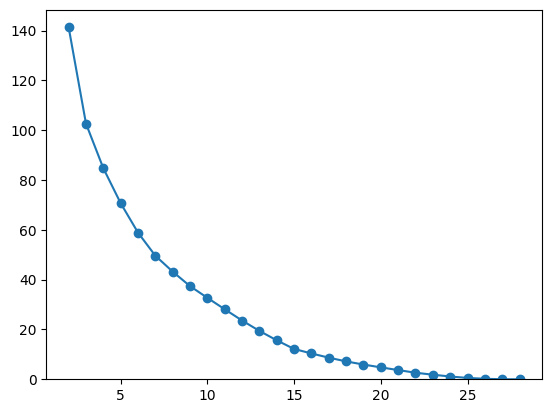

In [89]:
# Create plot
fig, ax = plt.subplots()
ax.plot(twssdf.nbr_cluster, twssdf.twss, 'o-')

# Force y-axis to start at 0
ax.set_ylim(bottom=0)  # Ensures minimum y-value is 0
plt.show()

In [90]:
#prapre a dataframe that will hold calinski-harabasz score
max_number_cluster = min(30, countries_ue.shape[0] - 1)
cahadf = pd.DataFrame({
    'nbr_cluster': range(2, max_number_cluster),
    'calinski_harabasz_score': [np.nan] * (max_number_cluster-2)
})
cahadf.head()

,nbr_cluster,calinski_harabasz_score
0,2,NaN
1,3,NaN
2,4,NaN
3,5,NaN
4,6,NaN


In [91]:
for nbr_cluster in cahadf.nbr_cluster:
  cluster_labels = fcluster(model_applied_scipy, t=nbr_cluster, criterion='maxclust')
  cahadf.loc[cahadf.nbr_cluster == nbr_cluster, 'calinski_harabasz_score'] = metrics.calinski_harabasz_score(X_stand, cluster_labels)

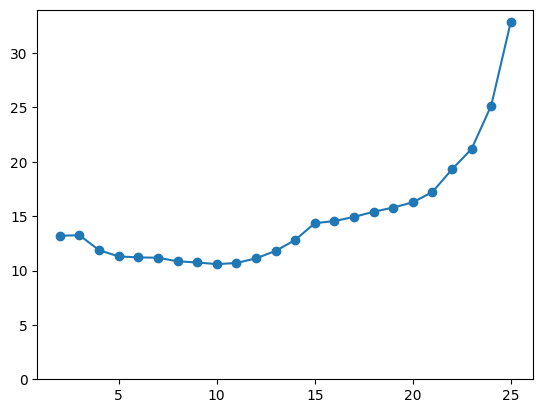

In [92]:
# Create plot
fig, ax = plt.subplots()
ax.plot(cahadf.nbr_cluster, cahadf.calinski_harabasz_score, 'o-')

# Force y-axis to start at 0
ax.set_ylim(bottom=0)  # Ensures minimum y-value is 0
plt.show()

In [93]:
# Clustering via k-means
# https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
from sklearn.cluster import KMeans
countries_ue['cluster_5_kmeans'] = KMeans(n_clusters=5, random_state=10, init='k-means++').fit_predict(X_stand)
countries_ue

,Pays,PIB,Dep_pub,Rev_net,Esp_vie,Chomage,Education,Gini,Securite,Adhesion,OCDE,Localisation,Rating,cluster_5,cluster_5_scikit,cluster_5_kmeans
0,BE,32700.0,17187.5,20.8,80.3,8.3,30.0,26.6,96.3,1957,OCDE,Ouest,2,1,0,1
1,BG,4800.0,1790.8,15.1,73.8,10.3,20.7,33.2,18.3,2007,Non-OCDE,Est,4,5,3,3
2,CZ,14300.0,6261.6,16.6,77.7,7.3,15.3,24.9,31.7,2004,Non-OCDE,Est,3,2,2,4
3,DK,42500.0,24562.8,26.7,79.3,7.5,29.5,26.9,88.9,1973,OCDE,Nord,1,1,0,1
4,DE,30500.0,14503.3,17.2,80.5,7.1,24.3,29.3,74.0,1957,OCDE,Ouest,1,2,2,1
5,EE,10700.0,4348.6,20.9,76.0,16.9,34.1,31.3,36.1,2004,OCDE,Est,3,4,4,2
6,IE,35000.0,23073.5,10.2,81.0,13.7,33.0,33.2,23.1,1973,OCDE,Ouest,2,3,1,0
7,GR,19600.0,10091.1,6.9,80.6,12.6,19.6,32.9,34.2,1981,OCDE,Sud,5,3,1,0
8,ES,22800.0,10410.6,14.9,82.3,20.1,25.8,33.9,50.8,1986,OCDE,Sud,2,3,1,0
9,FR,29900.0,16901.1,18.8,81.9,9.7,24.4,29.8,56.1,1957,OCDE,Ouest,1,2,2,1


In [94]:
countries_ue.groupby(['cluster_5', 'cluster_5_kmeans']).size()

cluster_5  cluster_5_kmeans
1          1                   6
2          1                   4
           4                   5
3          0                   4
4          2                   3
5          3                   5
dtype: int64

In [95]:
# depending on the value of random_state in KMeans function, we don't have the same result.
# Can you explain it?
metrics.adjusted_rand_score(countries_ue['cluster_5'], countries_ue['cluster_5_kmeans'])

0.6156679275333466